# Import Library

In [1]:
import emoji
import pandas as pd
import re
from pathlib import Path
import ast
import numpy as np
import string

# Import Dataset

In [2]:
df = pd.read_csv("dataset/new_combined_data.csv", encoding='utf-8-sig')
df

,comment_text,true_sentiment,type
0,Pemasangan baru tidak ada kelanjutan setelah s...,Negatif,Pernyataan
1,Sama naik semua ini juga komplen..biasanya cum...,Negatif,Pernyataan
2,Min kalau puteran PDAM dol itu sya ngadu kesia...,Negatif,Pertanyaan
3,Denda PDAM telat ngalah2in pinjol 50k jadi 150...,Negatif,Pernyataan
4,Air ya klo pagi dan jam 3 sore kenapa selalu mati,Negatif,Pertanyaan
...,...,...,...
29502,@pratyaharasamadhi selamat malam pak mhn infor...,Negatif,Pertanyaan
29503,"@hellow_vee92 Selamat malam pak/bu, mohon maaf...",Negatif,Pernyataan
29504,"@hellow_vee92 Selamat malam pak/bu, mohon maaf...",Negatif,Pernyataan
29505,"@vii.4dity Selamat malam pak/bu, mohon maaf at...",Negatif,Pernyataan


# Generate Comment ID

In [3]:
# Tambahkan comment_id sebagai kolom pertama dengan nomor urut 1 sampai akhir data
if "comment_id" in df.columns:
    df = df.drop(columns=["comment_id"])
df.insert(0, "comment_id", range(1, len(df) + 1))
df.head()

,comment_id,comment_text,true_sentiment,type
0,1,Pemasangan baru tidak ada kelanjutan setelah s...,Negatif,Pernyataan
1,2,Sama naik semua ini juga komplen..biasanya cum...,Negatif,Pernyataan
2,3,Min kalau puteran PDAM dol itu sya ngadu kesia...,Negatif,Pertanyaan
3,4,Denda PDAM telat ngalah2in pinjol 50k jadi 150...,Negatif,Pernyataan
4,5,Air ya klo pagi dan jam 3 sore kenapa selalu mati,Negatif,Pertanyaan


# Removing Duplicates

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

# Preparing Emoji Dataset

In [6]:
df_emoji = pd.read_csv('Dictionary/emoji.csv', index_col=0)

In [7]:
# Ganti spasi dengan underscore pada kolom 'name'
df_emoji['name'] = df_emoji['name'].str.replace(' ', '_')
df_emoji['name'] = df_emoji['name'].str.replace('-', '_')
df_emoji['name'] = df_emoji['name'].str.replace('⊛_', '')
df_emoji['name'] = df_emoji['name'].str.replace('"', '')
df_emoji['name'] = df_emoji['name'].str.replace(':', '')
df_emoji['name'] = df_emoji['name'].str.replace(',', '')
df_emoji['name'] = df_emoji['name'].str.replace("'", "")
# Tampilkan 5 baris pertama untuk memastikan hasilnya
print(df_emoji.head())

                              name
0                    grinning_face
1      grinning_face_with_big_eyes
2  grinning_face_with_smiling_eyes
3   beaming_face_with_smiling_eyes
4          grinning_squinting_face


In [8]:
df_emoji.to_csv('Dictionary/emoji_underscore.csv', index=True)

In [9]:
df_emoji

,name
0,grinning_face
1,grinning_face_with_big_eyes
2,grinning_face_with_smiling_eyes
3,beaming_face_with_smiling_eyes
4,grinning_squinting_face
...,...
1811,flag_Zambia
1812,flag_Zimbabwe
1813,flag_England
1814,flag_Scotland


# Removing PDAM Feedback

In [10]:
# Hapus baris yang comment_text-nya diakhiri dengan keyword -w, -v, -m, -n, atau -s
import re

jumlah_awal = len(df)
mask = df['comment_text'].str.strip().str.contains(r'\s-[wvmns]\s*$', flags=re.IGNORECASE, na=False)

df = df[~mask].reset_index(drop=True)

jumlah_akhir = len(df)
jumlah_dihapus = jumlah_awal - jumlah_akhir

print(f"Jumlah baris awal   : {jumlah_awal}")
print(f"Jumlah baris dihapus: {jumlah_dihapus}")
print(f"Jumlah baris tersisa: {jumlah_akhir}")

Jumlah baris awal   : 29507
Jumlah baris dihapus: 9332
Jumlah baris tersisa: 20175


# Cleansing

In [11]:
import pandas as pd
import re
from pathlib import Path

# --- 1. Baca daftar emoji dari file emoji_underscore.csv ---
emoji_df = pd.read_csv('Dictionary/emoji_underscore.csv')
emoji_df['name'] = emoji_df['name'].astype(str).str.strip()

# Buat pola regex berdasarkan nama emoji (format :emoji_name:)
emoji_names = [re.escape(name) for name in emoji_df['name'] if name]
emoji_pattern = re.compile(r':(' + '|'.join(emoji_names) + r'):', flags=re.IGNORECASE)

ALLOWED_PUNCTUATION = ".,?!"

def retain_allowed_symbols(text):
    if pd.isna(text):
        return ""

    text = str(text)
    return re.sub(rf"[^a-zA-Z\s{re.escape(ALLOWED_PUNCTUATION)}]", " ", text)

# --- 2. Fungsi pembersihan teks ---
def clean_text(text):
    
    if pd.isna(text):
        return ''
    
    text = str(text).lower()

    # =========================================
    # Hapus emoji
    # =========================================
    text = emoji_pattern.sub('', text)

    # =========================================
    # Hapus URL
    # =========================================
    text = re.sub(r'http\S+|www.\S+', '', text)

    # =========================================
    # Hapus tanda hubung "-"
    # =========================================
    text = re.sub('-', ' ', text)

    # =========================================
    # Hapus mention dan hashtag
    # =========================================
    text = re.sub(r'@\w+|#\w+', '', text)

    # =========================================
    # Hapus angka
    # =========================================
    text = re.sub(r'\d+', '', text)

    # =========================================
    # Hapus karakter selain huruf dan . , ! ?
    # =========================================
    text = retain_allowed_symbols(text)

    # =========================================
    # Hapus duplikasi punctuation
    # =========================================
    text = re.sub(r"\.{2,}", " . ", text)
    text = re.sub(r"\,{2,}", " , ", text)
    text = re.sub(r"\!{2,}", " ! ", text)
    text = re.sub(r"\?{2,}", " ? ", text)

    # =========================================
    # Hapus spasi berlebih
    # =========================================
    text = re.sub(r'\s+', ' ', text).strip()

    # =========================================
    # Tambahkan spasi sebelum dan sesudah punctuation (. , ! ?)
    # =========================================
    text = re.sub(r'([.,!?])', r' \1 ', text)

    # =========================================
    # Hapus punctuation tertentu (kecuali . , ! ?)
    # =========================================
    text = re.sub(r"[`~@#$%^&*()_+={}\[\]\\\/<>\":;]", " ", text)

    return text


# Terapkan fungsi clean_text ke kolom comment_text
df['cleaned_text'] = df['comment_text'].apply(clean_text)


# --- 4. Hapus baris kosong ---
before = len(df)
df = df[df['cleaned_text'].str.strip().astype(bool)]
after = len(df)
df.to_csv("output_skenario_1/cleaned_combined_data.csv", index=False, encoding='utf-8-sig')

print(f"🧹 {before - after} baris dihapus karena hanya berisi emoji atau kosong.")

🧹 1157 baris dihapus karena hanya berisi emoji atau kosong.


In [12]:
print(df['cleaned_text'])

0        pemasangan baru tidak ada kelanjutan setelah s...
1        sama naik semua ini juga komplen  .  biasanya ...
2        min kalau puteran pdam dol itu sya ngadu kesia...
3        denda pdam telat ngalahin pinjol k jadi k parahhh
4          air ya klo pagi dan jam sore kenapa selalu mati
                               ...                        
20170    ancen tuman  .  banyu mati ra kondo disik  .  ...
20171    sak jane laporane wong iki bener di respon tah...
20172    kebiasaan pdam ,  klo mati gk woro dulu  .  ad...
20173                sudah lapor tapi belum nyala seharian
20174    min kok durung ono update info e ,  wes ditind...
Name: cleaned_text, Length: 19018, dtype: object


# Stopword Removal + Normalization

In [13]:
import nltk
import json
import string
import pandas as pd
from nltk.tokenize import word_tokenize

# Pastikan tokenizer tersedia
nltk.download('punkt', quiet=True)

# --- Load stopwords ---
with open("Dictionary/combined_stop_words.txt", "r", encoding="utf-8") as f:
    stop_words = set(f.read().splitlines())

# --- Load slang dictionary ---
with open("Dictionary/update_combined_slang_words.json", "r", encoding="utf-8") as f:
    slang_words = json.load(f)


# =========================================================
# Punctuation yang ingin dipertahankan
# =========================================================
keep_punctuation = {".", ",", "!", "?"}


# --- Fungsi Stopword Removal + Slang Formalization ---
def formalize_text(text):

    if pd.isna(text) or not isinstance(text, str):
        return ""

    # Tokenisasi
    tokens = word_tokenize(text.lower())

    # Slang formalization
    normalized_tokens = [slang_words.get(w, w) for w in tokens]

    # Stopword removal (kecuali punctuation tertentu)
    filtered_tokens = [
        w for w in normalized_tokens
        if (
            w not in stop_words and
            (w not in string.punctuation or w in keep_punctuation) and
            w.strip()
        )
    ]

    return " ".join(filtered_tokens)


# Terapkan pada cleaned_text
df['normalized_text'] = df['cleaned_text'].apply(formalize_text)

df.to_csv("output_skenario_1/normalized_combined_data.csv", index=False, encoding='utf-8-sig')

print(df[['cleaned_text', 'normalized_text']].head().to_markdown())

|    | cleaned_text                                                                                                                            | normalized_text                                                                                                                                |
|---:|:----------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------|
|  0 | pemasangan baru tidak ada kelanjutan setelah survey .  padahal katanya bisa komplain cs lewat wa . sedangkan di wa gak ada tanggapan  . | pemasangan baru tidak ada kelanjutan survey . padahal katanya komplain pelayanan pelanggan whatsapp . sedangkan whatsapp tidak ada tanggapan . |
|  1 | sama naik semua ini juga komplen  .  biasanya cuma an sekrang an  .  duh semua serba membayar to jadi g percaya sama pemeri

# Drop Empty row

In [14]:
# --- Hapus baris dengan normalized_text kosong ---
before = len(df)

df = df[
    df['normalized_text'].notna() & 
    (df['normalized_text'].astype(str).str.strip() != "")
]

after = len(df)

print("✅ Baris kosong pada kolom 'normalized_text' berhasil dihapus.")
print(f"🗑️ Total baris dihapus: {before - after}")

# Simpan dataset
# df.to_csv("Output/cleaned_normalized_dataset.csv", index=False, encoding='utf-8-sig')

✅ Baris kosong pada kolom 'normalized_text' berhasil dihapus.
🗑️ Total baris dihapus: 335


# Segmentasi Teks

In [15]:
import pandas as pd
import re
from pathlib import Path

# =========================================================
# 1️⃣ LOAD LIST KONJUNGSI
# =========================================================

with open("Dictionary/augmentation_text_dict.txt", "r", encoding="utf-8") as f:
    conjunctions = [line.strip().lower() for line in f if line.strip()]

conjunctions = sorted(set(conjunctions), key=len, reverse=True)
conjunction_pattern = r'\b(?:' + '|'.join(re.escape(conj) for conj in conjunctions) + r')\b'


# =========================================================
# 2️⃣ FUNGSI SEGMENTASI BERDASARKAN KONJUNGSI
# =========================================================

def split_text_to_segments(text):
    if pd.isna(text) or not isinstance(text, str):
        return []
    text = text.strip()
    if not text:
        return []
    matches = list(re.finditer(conjunction_pattern, text.lower()))
    if not matches:
        return [text]
    segments = []
    start_idx = 0
    for match in matches:
        segment = text[start_idx:match.start()].strip()
        if segment:
            segments.append(segment)
        start_idx = match.start()
    last_segment = text[start_idx:].strip()
    if last_segment:
        segments.append(last_segment)
    return segments


# =========================================================
# 3️⃣ BENTUK DATAFRAME HASIL SEGMENTASI
# =========================================================

df['_segments'] = df['normalized_text'].apply(split_text_to_segments)
df['sentence_1'] = df['_segments'].apply(lambda x: x[0] if x else '')
df['sentence_2'] = df['_segments'].apply(lambda x: ' '.join(x[1:]).strip() if len(x) > 1 else '')

segmented_df = df[['comment_id', 'comment_text', '_segments']].copy()
segmented_df = segmented_df.rename(columns={'_segments': 'segmented_text'})
segmented_df = segmented_df.explode('segmented_text', ignore_index=True)
segmented_df['segmented_text'] = segmented_df['segmented_text'].fillna('').astype(str).str.strip()
segmented_df = segmented_df[
    segmented_df['segmented_text'] != ''
][['comment_id', 'comment_text', 'segmented_text']].reset_index(drop=True)
segmented_df['comment_text'] = segmented_df['comment_text'].fillna('').astype(str).str.strip()
segmented_df['segment_order'] = segmented_df.groupby('comment_id').cumcount()

# Inisialisasi kolom true_aspect dan true_sentiment
if 'true_aspect' not in segmented_df.columns:
    segmented_df['true_aspect'] = pd.NA
if 'true_sentiment' not in segmented_df.columns:
    segmented_df['true_sentiment'] = pd.NA

segmented_df['true_aspect']   = segmented_df['true_aspect'].replace('', pd.NA)
segmented_df['true_sentiment'] = segmented_df['true_sentiment'].replace('', pd.NA)


# =========================================================
# 4️⃣ SINKRONISASI GROUND TRUTH
#    Hanya update isi kolom true_aspect & true_sentiment
#    pada baris yang sudah ada di segmented_df.
#    TIDAK ada penambahan baris baru.
# =========================================================

reference_paths = [
    Path('Dataset/segmented_dataset.csv'),
]

for reference_path in reference_paths:
    if not reference_path.exists():
        continue

    reference_df = pd.read_csv(reference_path, encoding='utf-8-sig')
    reference_df['comment_id']     = reference_df['comment_id'].astype(str).str.strip()
    reference_df['comment_text']   = reference_df['comment_text'].fillna('').astype(str).str.strip()
    reference_df['segmented_text'] = reference_df['segmented_text'].fillna('').astype(str).str.strip()
    segmented_df['comment_id']     = segmented_df['comment_id'].astype(str).str.strip()

    # ----------------------------------------------------------
    # UPDATE true_aspect
    # Prioritas 1: cocok berdasarkan comment_id + segmented_text
    # ----------------------------------------------------------
    if {'comment_id', 'segmented_text', 'true_aspect'}.issubset(reference_df.columns):
        ref_aspect = (
            reference_df[['comment_id', 'segmented_text', 'true_aspect']]
            .replace('', pd.NA)
            .dropna(subset=['true_aspect'])
            .drop_duplicates(subset=['comment_id', 'segmented_text'])
        )

        # Simpan jumlah baris sebelum merge sebagai kontrol
        n_before = len(segmented_df)

        segmented_df = segmented_df.merge(
            ref_aspect.rename(columns={'true_aspect': '_ref_aspect'}),
            on=['comment_id', 'segmented_text'],
            how='left'         # hanya baris yang sudah ada di segmented_df yang diproses
        )

        # Jika merge menghasilkan duplikasi baris karena referensi tidak unik,
        # ambil hanya baris pertama per index asli lalu kembalikan ke ukuran semula
        if len(segmented_df) != n_before:
            segmented_df = segmented_df.groupby(
                segmented_df.index // (len(segmented_df) // n_before), sort=False
            ).first().reset_index(drop=True)

        # Update hanya jika ground truth ada dan kolom saat ini kosong
        mask = segmented_df['_ref_aspect'].notna()
        segmented_df.loc[mask, 'true_aspect'] = segmented_df.loc[mask, '_ref_aspect']
        segmented_df.drop(columns=['_ref_aspect'], inplace=True)

        # ----------------------------------------------------------
        # Prioritas 2 (fallback): cocok berdasarkan comment_id + segment_order
        # Hanya untuk baris yang true_aspect masih kosong
        # Syarat: jumlah segmen di segmented_df == jumlah segmen di referensi
        # ----------------------------------------------------------
        ref_order = (
            reference_df[['comment_id', 'comment_text', 'segmented_text', 'true_aspect']]
            .replace('', pd.NA)
            .dropna(subset=['true_aspect'])
            .copy()
        )
        ref_order['segment_order'] = ref_order.groupby('comment_id').cumcount()

        # Hanya comment_id yang jumlah segmennya sama antara segmented_df dan referensi
        count_cur = segmented_df.groupby('comment_id').size().rename('n_cur')
        count_ref = ref_order.groupby('comment_id').size().rename('n_ref')
        same_count_ids = count_cur.to_frame().join(count_ref, how='inner')
        same_count_ids = same_count_ids[same_count_ids['n_cur'] == same_count_ids['n_ref']].index.tolist()

        ref_order_filtered = (
            ref_order[ref_order['comment_id'].isin(same_count_ids)]
            [['comment_id', 'comment_text', 'segment_order', 'true_aspect']]
            .drop_duplicates(subset=['comment_id', 'comment_text', 'segment_order'])
            .rename(columns={'true_aspect': '_ref_aspect_order'})
        )

        n_before = len(segmented_df)
        segmented_df = segmented_df.merge(
            ref_order_filtered,
            on=['comment_id', 'comment_text', 'segment_order'],
            how='left'
        )

        # Jaga agar tidak ada baris tambahan akibat duplikasi referensi
        assert len(segmented_df) == n_before, (
            f"Baris bertambah setelah merge fallback true_aspect: "
            f"{n_before} -> {len(segmented_df)}"
        )

        # Update hanya pada baris yang true_aspect masih kosong
        mask_fallback = segmented_df['_ref_aspect_order'].notna() & segmented_df['true_aspect'].isna()
        segmented_df.loc[mask_fallback, 'true_aspect'] = segmented_df.loc[mask_fallback, '_ref_aspect_order']
        segmented_df.drop(columns=['_ref_aspect_order'], inplace=True)

    # ----------------------------------------------------------
    # UPDATE true_sentiment
    # Cocok berdasarkan comment_id + comment_text
    # ----------------------------------------------------------
    if {'comment_id', 'comment_text', 'true_sentiment'}.issubset(reference_df.columns):
        ref_sentiment = (
            reference_df[['comment_id', 'comment_text', 'true_sentiment']]
            .replace('', pd.NA)
            .dropna(subset=['true_sentiment'])
            .drop_duplicates(subset=['comment_id', 'comment_text'])
        )

        n_before = len(segmented_df)
        segmented_df = segmented_df.merge(
            ref_sentiment.rename(columns={'true_sentiment': '_ref_sentiment'}),
            on=['comment_id', 'comment_text'],
            how='left'
        )

        assert len(segmented_df) == n_before, (
            f"Baris bertambah setelah merge true_sentiment: "
            f"{n_before} -> {len(segmented_df)}"
        )

        mask = segmented_df['_ref_sentiment'].notna()
        segmented_df.loc[mask, 'true_sentiment'] = segmented_df.loc[mask, '_ref_sentiment']
        segmented_df.drop(columns=['_ref_sentiment'], inplace=True)

    break  # Gunakan file referensi pertama yang ditemukan


# =========================================================
# 5️⃣ HASIL
# =========================================================

segmented_df = segmented_df.drop(columns=['segment_order'])

print(
    segmented_df[
        ['comment_id', 'comment_text', 'segmented_text', 'true_aspect', 'true_sentiment']
    ]
)

segmented_df.to_csv("output_skenario_1/segmented_data.csv", index=False, encoding='utf-8-sig')

      comment_id                                       comment_text  \
0              1  Pemasangan baru tidak ada kelanjutan setelah s...   
1              1  Pemasangan baru tidak ada kelanjutan setelah s...   
2              1  Pemasangan baru tidak ada kelanjutan setelah s...   
3              2  Sama naik semua ini juga komplen..biasanya cum...   
4              3  Min kalau puteran PDAM dol itu sya ngadu kesia...   
...          ...                                                ...   
21677      29499  sak jane laporane wong² iki bener² di respon t...   
21678      29500  Kebiasaan PDAM, klo mati gk woro2 dulu... Ada ...   
21679      29501              Sudah lapor tapi belum nyala seharian   
21680      29501              Sudah lapor tapi belum nyala seharian   
21681      29502  min kok durung ono update info e, wes ditindak...   

                                          segmented_text  \
0          pemasangan baru tidak ada kelanjutan survey .   
1      padahal katanya komp

# Evaluasi Segmentasi Teks

In [ ]:
# =========================================================
# EVALUASI SEGMENTASI TEKS
# =========================================================

# Expected: hasil split langsung dari normalized_text di df asli
expected_segments = df[['comment_id', 'comment_text', 'normalized_text']].copy()
expected_segments['comment_id'] = expected_segments['comment_id'].astype(str).str.strip()
expected_segments['expected_segments'] = expected_segments['normalized_text'].apply(split_text_to_segments)

# Actual: segmen yang benar-benar tersimpan di segmented_df
actual_segments = (
    segmented_df
    .groupby('comment_id', sort=False)['segmented_text']
    .apply(list)
    .reset_index(name='actual_segments')
)
actual_segments['comment_id'] = actual_segments['comment_id'].astype(str).str.strip()

# Gabungkan expected vs actual
seg_eval = expected_segments.merge(actual_segments, on='comment_id', how='left', suffixes=('_expected', '_actual'))
seg_eval['actual_segments'] = seg_eval['actual_segments'].apply(lambda x: x if isinstance(x, list) else [])

# Bandingkan: expected harus sama persis dengan actual
seg_eval['is_correct_split'] = seg_eval.apply(
    lambda row: row['expected_segments'] == row['actual_segments'],
    axis=1
)

# Metrik evaluasi
total_comments          = len(seg_eval)
comments_with_conjunction = int(seg_eval['normalized_text'].fillna('').astype(str).str.contains(conjunction_pattern, regex=True).sum())
total_segments          = int(segmented_df.shape[0])
correct_comments        = int(seg_eval['is_correct_split'].sum())
incorrect_comments      = total_comments - correct_comments
segmentation_accuracy   = (correct_comments / total_comments) * 100 if total_comments else 0

print('=' * 80)
print('Evaluasi Segmentasi Teks')
print('=' * 80)
print(f'Total Comment              : {total_comments}')
print(f'Comment dengan Konjungsi   : {comments_with_conjunction}')
print(f'Total Segmen               : {total_segments}')
print(f'Comment Benar              : {correct_comments}')
print(f'Comment Salah              : {incorrect_comments}')
print(f'Akurasi Segmentasi         : {segmentation_accuracy:.2f}%')

display(seg_eval.loc[~seg_eval['is_correct_split'], [
    'comment_id',
    'comment_text',        # kolom tunggal karena tidak ada suffix _expected/_actual pada comment_text
    'expected_segments',
    'actual_segments'
]].head(10))

# seg_eval.to_csv("output_skenario_1/segmentation_evaluation.csv", index=False, encoding='utf-8-sig')

Evaluasi Segmentasi Teks
Total Comment              : 18683
Comment dengan Konjungsi   : 2489
Total Segmen               : 21682
Comment Benar              : 18683
Comment Salah              : 0
Akurasi Segmentasi         : 100.00%


,comment_id,comment_text,expected_segments,actual_segments


# Drop Data yang Hanya Berisi 1 Kata

In [17]:
# =========================================================
# DROP SEGMEN YANG HANYA BERISI 1 KATA
# =========================================================

jumlah_awal = len(segmented_df)

mask_1_kata = segmented_df['segmented_text'].str.strip().str.split().str.len() == 1
jumlah_dihapus = mask_1_kata.sum()

segmented_df = segmented_df[~mask_1_kata].reset_index(drop=True)

jumlah_akhir = len(segmented_df)

print(f"Jumlah baris awal   : {jumlah_awal}")
print(f"Jumlah baris dihapus: {jumlah_dihapus}")
print(f"Jumlah baris tersisa: {jumlah_akhir}")


Jumlah baris awal   : 21682
Jumlah baris dihapus: 1188
Jumlah baris tersisa: 20494


# Tokenization

In [ ]:
from nltk.tokenize import word_tokenize
import pandas as pd
import re


# =========================================================
# FUNGSI TOKENIZATION
# =========================================================

def tokenize_text(text):
    
    if pd.isna(text) or not isinstance(text, str) or text.strip() == "":
        return []
    
    # =====================================================
    # Pisahkan punctuation menjadi token tersendiri
    # =====================================================
    text = re.sub(r'([.,!?])', r' \1 ', text)
    
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenisasi
    return word_tokenize(text)


# =========================================================
# TOKENIZATION PADA DATA HASIL SEGMENTASI
# =========================================================

segmented_df['tokens_segmented_text'] = segmented_df['segmented_text'].apply(tokenize_text)


# =========================================================
# HASIL
# =========================================================

print(
    segmented_df[
        [
            'comment_id',
            'comment_text',
            'segmented_text',
            'tokens_segmented_text'
        ]
    ]
)

# segmented_df.to_csv("output_skenario_1/segmented_tokenized_data.csv", index=False, encoding='utf-8-sig')

      comment_id                                       comment_text  \
0              1  Pemasangan baru tidak ada kelanjutan setelah s...   
1              1  Pemasangan baru tidak ada kelanjutan setelah s...   
2              1  Pemasangan baru tidak ada kelanjutan setelah s...   
3              2  Sama naik semua ini juga komplen..biasanya cum...   
4              3  Min kalau puteran PDAM dol itu sya ngadu kesia...   
...          ...                                                ...   
20489      29499  sak jane laporane wong² iki bener² di respon t...   
20490      29500  Kebiasaan PDAM, klo mati gk woro2 dulu... Ada ...   
20491      29501              Sudah lapor tapi belum nyala seharian   
20492      29501              Sudah lapor tapi belum nyala seharian   
20493      29502  min kok durung ono update info e, wes ditindak...   

                                          segmented_text  \
0          pemasangan baru tidak ada kelanjutan survey .   
1      padahal katanya komp

# Stemming

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# =========================================================
# 1️⃣ INISIALISASI STEMMER
# =========================================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()


# =========================================================
# 2️⃣ FUNGSI STEMMING
# =========================================================

def stem_tokens(tokens):

    keep_punctuation = {'.', ',', '?', '!'}

    if isinstance(tokens, str):
        tokens = tokenize_text(tokens)

    if not isinstance(tokens, list):
        return ""

    stemmed_tokens = []

    for token in tokens:
        if token in keep_punctuation:
            stemmed_tokens.append(token)
        else:
            stemmed_tokens.append(stemmer.stem(token))

    return " ".join(stemmed_tokens)


# =========================================================
# 3️⃣ STEMMING PADA TOKEN HASIL SEGMENTASI
# =========================================================

segmented_df['stemmed_segmented_text'] = segmented_df['tokens_segmented_text'].apply(stem_tokens)


# =========================================================
# 4️⃣ HASIL
# =========================================================

print(
    segmented_df[
        [
            'comment_id',
            'comment_text',
            'segmented_text',
            'tokens_segmented_text',
            'stemmed_segmented_text'
        ]
    ]
)


# =========================================================
# 5️⃣ SIMPAN DATASET
# =========================================================

# segmented_df[
#     [
#         'comment_id',
#         'comment_text',
#         'segmented_text',
#         'tokens_segmented_text',
#         'stemmed_segmented_text'
#     ]
# ].to_csv("output_skenario_1/final_segmented_stemmed_dataset.csv", index=False, encoding='utf-8-sig')

      comment_id                                       comment_text  \
0              1  Pemasangan baru tidak ada kelanjutan setelah s...   
1              1  Pemasangan baru tidak ada kelanjutan setelah s...   
2              1  Pemasangan baru tidak ada kelanjutan setelah s...   
3              2  Sama naik semua ini juga komplen..biasanya cum...   
4              3  Min kalau puteran PDAM dol itu sya ngadu kesia...   
...          ...                                                ...   
20489      29499  sak jane laporane wong² iki bener² di respon t...   
20490      29500  Kebiasaan PDAM, klo mati gk woro2 dulu... Ada ...   
20491      29501              Sudah lapor tapi belum nyala seharian   
20492      29501              Sudah lapor tapi belum nyala seharian   
20493      29502  min kok durung ono update info e, wes ditindak...   

                                          segmented_text  \
0          pemasangan baru tidak ada kelanjutan survey .   
1      padahal katanya komp

# Data Split for Aspect Based
# Data Train: Not Segmented Data | Data Test: Segmented Data

In [20]:
# =========================================================
# 1️⃣ SIAPKAN DATA SEGMENTASI BERLABEL
# =========================================================

segmented_labeled_df = segmented_df.copy()

if 'true_aspect' not in segmented_labeled_df.columns:
    raise ValueError(
        'Kolom true_aspect belum ada pada variabel segmented_df. Pastikan segmented_df sudah memuat kolom true_aspect sebelum data split dijalankan.'
    )

segmented_labeled_df = segmented_labeled_df.copy()
segmented_labeled_df['comment_text'] = segmented_labeled_df['comment_text'].fillna('').astype(str)
segmented_labeled_df['segmented_text'] = segmented_labeled_df['segmented_text'].fillna('').astype(str).str.strip()
segmented_labeled_df['true_aspect'] = segmented_labeled_df['true_aspect'].fillna('').astype(str).str.strip()

if 'tokens_segmented_text' not in segmented_labeled_df.columns:
    segmented_labeled_df['tokens_segmented_text'] = segmented_labeled_df['segmented_text'].apply(tokenize_text)

if 'stemmed_segmented_text' not in segmented_labeled_df.columns:
    segmented_labeled_df['stemmed_segmented_text'] = segmented_labeled_df['tokens_segmented_text'].apply(stem_tokens)
else:
    segmented_labeled_df['stemmed_segmented_text'] = segmented_labeled_df['stemmed_segmented_text'].fillna('').astype(str).str.strip()

segmented_labeled_df = segmented_labeled_df[
    (segmented_labeled_df['segmented_text'] != '') &
    (segmented_labeled_df['true_aspect'] != '')
].reset_index(drop=True)


# =========================================================
# 2️⃣ DATA SPLIT BERDASARKAN COMMENT_ID
# =========================================================

# comment_id yang hanya muncul sekali dianggap sebagai komentar
# yang tidak tersegmentasi, sehingga dipakai sebagai data train.
comment_id_counts = segmented_labeled_df['comment_id'].value_counts()
single_comment_ids = comment_id_counts[comment_id_counts == 1].index
duplicated_comment_ids = comment_id_counts[comment_id_counts > 1].index

df_train_for_ab = segmented_labeled_df[
    segmented_labeled_df['comment_id'].isin(single_comment_ids)
].reset_index(drop=True)

# Test hanya menggunakan data yang benar-benar tersegmentasi,
# yaitu comment_id yang muncul lebih dari satu kali.
df_test_for_ab = segmented_labeled_df[
    segmented_labeled_df['comment_id'].isin(duplicated_comment_ids)
].reset_index(drop=True)

split_summary_df = pd.DataFrame([
    {'kelompok': 'Train (comment_id tunggal)', 'jumlah_baris': len(df_train_for_ab), 'jumlah_comment_id': df_train_for_ab['comment_id'].nunique()},
    {'kelompok': 'Test (data tersegmentasi)', 'jumlah_baris': len(df_test_for_ab), 'jumlah_comment_id': df_test_for_ab['comment_id'].nunique()},
    {'kelompok': 'Comment ID tunggal', 'jumlah_baris': int(comment_id_counts[comment_id_counts == 1].sum()), 'jumlah_comment_id': len(single_comment_ids)},
    {'kelompok': 'Comment ID tersegmentasi', 'jumlah_baris': int(comment_id_counts[comment_id_counts > 1].sum()), 'jumlah_comment_id': len(duplicated_comment_ids)}
])

print('===========================================')
print('RINGKASAN DATA SPLIT ASPECT BASED')
print('===========================================')
print(split_summary_df.to_markdown(index=False))

df_train_for_ab.to_csv("output_skenario_1/train_data_for_ab.csv", index=False, encoding='utf-8-sig')
df_test_for_ab.to_csv("output_skenario_1/test_data_for_ab.csv", index=False, encoding='utf-8-sig')


RINGKASAN DATA SPLIT ASPECT BASED
| kelompok                   |   jumlah_baris |   jumlah_comment_id |
|:---------------------------|---------------:|--------------------:|
| Train (comment_id tunggal) |          15273 |               15273 |
| Test (data tersegmentasi)  |           5092 |                2264 |
| Comment ID tunggal         |          15273 |               15273 |
| Comment ID tersegmentasi   |           5092 |                2264 |


# Data Split for Sentiment Analysis
# Data Train: Not Segmented Data | Data Test: 100% Data

In [21]:
# =========================================================
# 1️⃣ SIAPKAN DATA SEGMENTASI BERLABEL
# =========================================================

segmented_labeled_df = segmented_df.copy()

if 'true_aspect' not in segmented_labeled_df.columns:
    raise ValueError(
        'Kolom true_aspect belum ada pada variabel segmented_df. Pastikan segmented_df sudah memuat kolom true_aspect sebelum data split dijalankan.'
    )

segmented_labeled_df = segmented_labeled_df.copy()
segmented_labeled_df['comment_text'] = segmented_labeled_df['comment_text'].fillna('').astype(str)
segmented_labeled_df['segmented_text'] = segmented_labeled_df['segmented_text'].fillna('').astype(str).str.strip()
segmented_labeled_df['true_aspect'] = segmented_labeled_df['true_aspect'].fillna('').astype(str).str.strip()

if 'tokens_segmented_text' not in segmented_labeled_df.columns:
    segmented_labeled_df['tokens_segmented_text'] = segmented_labeled_df['segmented_text'].apply(tokenize_text)

if 'stemmed_segmented_text' not in segmented_labeled_df.columns:
    segmented_labeled_df['stemmed_segmented_text'] = segmented_labeled_df['tokens_segmented_text'].apply(stem_tokens)
else:
    segmented_labeled_df['stemmed_segmented_text'] = segmented_labeled_df['stemmed_segmented_text'].fillna('').astype(str).str.strip()

segmented_labeled_df = segmented_labeled_df[
    (segmented_labeled_df['segmented_text'] != '') &
    (segmented_labeled_df['true_aspect'] != '')
].reset_index(drop=True)


# =========================================================
# 2️⃣ DATA SPLIT BERDASARKAN COMMENT_ID
# =========================================================

# comment_id yang hanya muncul sekali dianggap sebagai komentar
# yang tidak tersegmentasi, sehingga dipakai sebagai data train.
comment_id_counts = segmented_labeled_df['comment_id'].value_counts()
single_comment_ids = comment_id_counts[comment_id_counts == 1].index
duplicated_comment_ids = comment_id_counts[comment_id_counts > 1].index

df_train = segmented_labeled_df[
    segmented_labeled_df['comment_id'].isin(single_comment_ids)
].reset_index(drop=True)

# Test menggunakan 100% data berlabel.
df_test = segmented_labeled_df.copy().reset_index(drop=True)

split_summary_df = pd.DataFrame([
    {'kelompok': 'Train (comment_id tunggal)', 'jumlah_baris': len(df_train), 'jumlah_comment_id': df_train['comment_id'].nunique()},
    {'kelompok': 'Test (100% data)', 'jumlah_baris': len(df_test), 'jumlah_comment_id': df_test['comment_id'].nunique()},
    {'kelompok': 'Comment ID tunggal', 'jumlah_baris': int(comment_id_counts[comment_id_counts == 1].sum()), 'jumlah_comment_id': len(single_comment_ids)},
    {'kelompok': 'Comment ID tersegmentasi', 'jumlah_baris': int(comment_id_counts[comment_id_counts > 1].sum()), 'jumlah_comment_id': len(duplicated_comment_ids)}
])

print('===========================================')
print('RINGKASAN DATA SPLIT ASPECT BASED')
print('===========================================')
print(split_summary_df.to_markdown(index=False))

df_train.to_csv("output_skenario_1/train_data.csv", index=False, encoding='utf-8-sig')
df_test.to_csv("output_skenario_1/test_data.csv", index=False, encoding='utf-8-sig')


RINGKASAN DATA SPLIT ASPECT BASED
| kelompok                   |   jumlah_baris |   jumlah_comment_id |
|:---------------------------|---------------:|--------------------:|
| Train (comment_id tunggal) |          15273 |               15273 |
| Test (100% data)           |          20365 |               17537 |
| Comment ID tunggal         |          15273 |               15273 |
| Comment ID tersegmentasi   |           5092 |                2264 |


# TF-IDF & Aspect Based Using Cosine Similarity

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# =========================================================
# 1️⃣ VECTORISASI TF-IDF (TRAIN DATA)
# Train menggunakan stemmed_segmented_text
# =========================================================

vectorizer = TfidfVectorizer(
    ngram_range=(1,3),
    min_df=2
)

X_train = vectorizer.fit_transform(df_train_for_ab['stemmed_segmented_text'])
train_aspects = df_train_for_ab['true_aspect'].to_numpy()


# =========================================================
# 2️⃣ FUNGSI PREDIKSI ASPEK
# =========================================================

PRIMARY_THRESHOLD = 0.60
LAINNYA_THRESHOLD = 0.18

def predict_aspect(text):

    if pd.isna(text) or str(text).strip() == "":
        return "Lainnya", 0

    X_test = vectorizer.transform([text])
    sims = cosine_similarity(X_test, X_train)[0]

    best_idx = sims.argmax()
    best_score = sims[best_idx]
    best_aspect = train_aspects[best_idx]

    if best_score < LAINNYA_THRESHOLD:
        return "Lainnya", best_score

    return best_aspect, best_score


# =========================================================
# 3️⃣ ASPECT BASED USING COSINE SIMILARITY
# =========================================================

predicted_aspects = []
similarity_scores = []

for _, row in df_test_for_ab.iterrows():
    text = row['stemmed_segmented_text']
    raw_aspect, score = predict_aspect(text)

    if raw_aspect != 'Lainnya' and score >= PRIMARY_THRESHOLD:
        final_aspect = raw_aspect
    elif raw_aspect != 'Lainnya' and score >= LAINNYA_THRESHOLD:
        final_aspect = raw_aspect
    else:
        final_aspect = 'Lainnya'

    predicted_aspects.append(final_aspect)
    similarity_scores.append(score)

df_test_for_ab['predicted_aspect'] = predicted_aspects
df_test_for_ab['similarity_score'] = similarity_scores
df_test_for_ab['is_correct'] = df_test_for_ab['true_aspect'] == df_test_for_ab['predicted_aspect']

output_cols = [
    'comment_id',
    'comment_text',
    'segmented_text',
    'tokens_segmented_text',
    'stemmed_segmented_text',
    'true_aspect',
    'predicted_aspect',
    'similarity_score'
]

df_test_for_ab[output_cols].to_csv(
    "output_skenario_1/trial_multi_aspect_classification_result.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Aspect based classification selesai")


✅ Aspect based classification selesai


# Aspect Based Evaluation

HASIL EVALUASI ASPECT BASED
Total Train Data        : 15273
Total Test Data         : 5092
Accuracy Score          : 0.7431
Weighted F1 Score       : 0.7418
Macro F1 Score          : 0.7052
Rata-rata F1 per Aspek  : 0.7052

Distribusi True Aspect:
| Aspek                      |   Jumlah |
|:---------------------------|---------:|
| Air Tidak Mengalir         |     1456 |
| Lainnya                    |     1451 |
| Pelayanan                  |      892 |
| Harga                      |      529 |
| Air Kotor/Bau              |      215 |
| Meteran (Macet/Bermasalah) |      179 |
| Pemasangan                 |      138 |
| Kebocoran                  |      102 |
| Pemakaian                  |       90 |
| Perubahan Kode Tarif       |       40 |

Statistik Predicted Aspect:
| predicted_aspect           |   Jumlah_Kemunculan |   Rata_rata_Similarity |
|:---------------------------|--------------------:|-----------------------:|
| Lainnya                    |                1823 |           

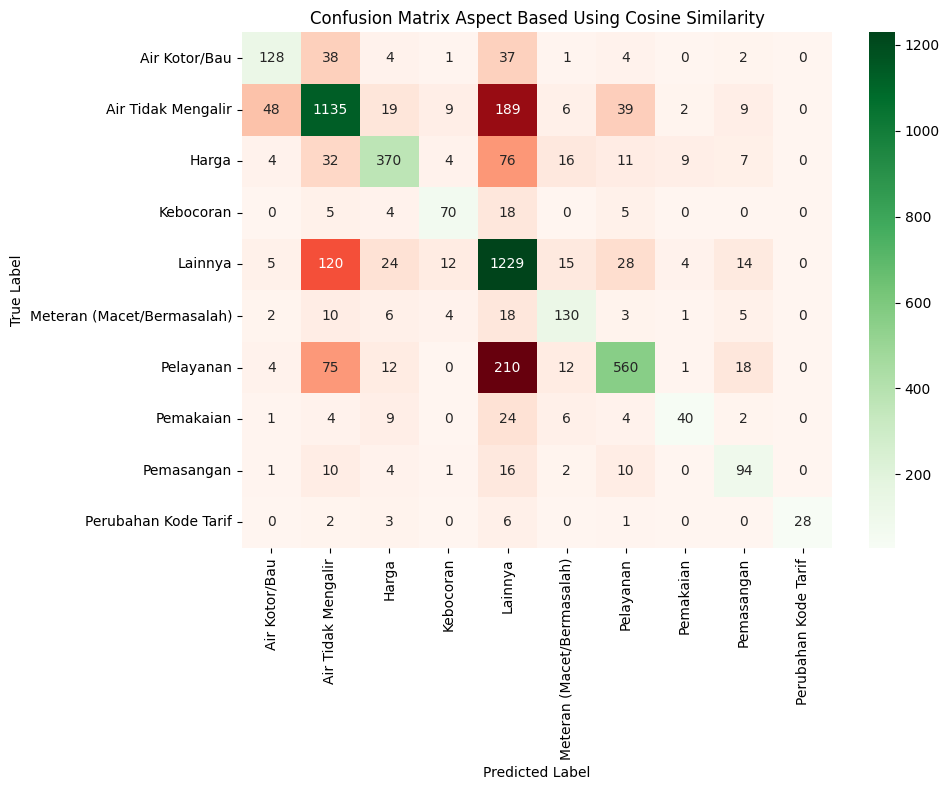


✅ Evaluasi aspect-based selesai


In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

# =========================================================
# ASPECT BASED EVALUATION
# =========================================================

accuracy = df_test_for_ab['is_correct'].mean()
weighted_f1 = f1_score(
    df_test_for_ab['true_aspect'],
    df_test_for_ab['predicted_aspect'],
    average='weighted',
    zero_division=0,
)
macro_f1 = f1_score(
    df_test_for_ab['true_aspect'],
    df_test_for_ab['predicted_aspect'],
    average='macro',
    zero_division=0,
)

labels = sorted(
    set(df_test_for_ab['true_aspect']).union(
        set(df_test_for_ab['predicted_aspect'])
    )
)
precision, recall, f1_per_aspect, support = precision_recall_fscore_support(
    df_test_for_ab['true_aspect'],
    df_test_for_ab['predicted_aspect'],
    labels=labels,
    zero_division=0,
)

f1_aspect_df = pd.DataFrame(
    {
        'Aspek': labels,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1_per_aspect,
        'Jumlah_True': support,
    }
)
f1_aspect_df[['Precision', 'Recall', 'F1_Score']] = f1_aspect_df[
    ['Precision', 'Recall', 'F1_Score']
].round(4)

aspect_stats = (
    df_test_for_ab.groupby('predicted_aspect')
    .agg(
        Jumlah_Kemunculan=('predicted_aspect', 'count'),
        Rata_rata_Similarity=('similarity_score', 'mean'),
    )
    .reset_index()
    .sort_values('Jumlah_Kemunculan', ascending=False)
)
aspect_stats['Rata_rata_Similarity'] = aspect_stats[
    'Rata_rata_Similarity'
].round(4)

true_aspect_distribution = (
    df_test_for_ab['true_aspect'].value_counts().reset_index()
)
true_aspect_distribution.columns = ['Aspek', 'Jumlah']

total_correct = int(df_test_for_ab['is_correct'].sum())
total_wrong = len(df_test_for_ab) - total_correct
average_f1_per_aspect = (
    f1_aspect_df['F1_Score'].mean() if not f1_aspect_df.empty else 0
)

print('===========================================')
print('HASIL EVALUASI ASPECT BASED')
print('===========================================')
print(f'Total Train Data        : {len(df_train_for_ab)}')
print(f'Total Test Data         : {len(df_test_for_ab)}')
print(f'Accuracy Score          : {accuracy:.4f}')
print(f'Weighted F1 Score       : {weighted_f1:.4f}')
print(f'Macro F1 Score          : {macro_f1:.4f}')
print(f'Rata-rata F1 per Aspek  : {average_f1_per_aspect:.4f}')
print()
print('Distribusi True Aspect:')
print(true_aspect_distribution.to_markdown(index=False))
print()
print('Statistik Predicted Aspect:')
print(aspect_stats.to_markdown(index=False))
print()
print('F1 Score Tiap Aspek:')
print(f1_aspect_df.to_markdown(index=False))
print()
print(f'Prediksi Benar          : {total_correct}')
print(f'Prediksi Salah          : {total_wrong}')
print(f'Total Akurasi           : {accuracy*100:.2f}%')
print(f'Error Rate              : {(1-accuracy)*100:.2f}%')

# Perhitungan Matriks Kebingungan
cm = confusion_matrix(
    df_test_for_ab['true_aspect'],
    df_test_for_ab['predicted_aspect'],
    labels=labels,
)
confusion_df = pd.DataFrame(cm, index=labels, columns=labels)

# ---------------------------------------------------------
# PROSES PLOTTING DENGAN DIAGONAL HIJAU KUSTOM
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# Membuat masker indeks untuk memisahkan posisi diagonal dan non-diagonal
mask_diagonal = np.eye(confusion_df.shape[0], dtype=bool)
mask_off_diagonal = ~mask_diagonal

# Lapisan 1: Gambar elemen di luar garis diagonal (warna biru pudar)
ax = sns.heatmap(
    confusion_df,
    annot=True,
    fmt='d',
    cmap='Reds',
    mask=mask_diagonal,
    cbar=False,
)

# Lapisan 2: Gambar elemen khusus garis diagonal saja (warna hijau)
sns.heatmap(
    confusion_df,
    annot=True,
    fmt='d',
    cmap='Greens',
    mask=mask_off_diagonal,
    ax=ax,
    cbar=True,
)

plt.title('Confusion Matrix Aspect Based Using Cosine Similarity')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# =========================================================
# SIMPAN DATA MISCLASSIFIED
# =========================================================

misclassified_df = df_test_for_ab.loc[
    ~df_test_for_ab['is_correct'],
    [
        'comment_id',
        'comment_text',
        'segmented_text',
        'stemmed_segmented_text',
        'true_aspect',
        'predicted_aspect',
        'similarity_score',
    ],
]

misclassified_df.to_csv(
    'output_skenario_1/trial_missclassified_multi_aspect_data.csv',
    index=False,
    encoding='utf-8-sig',
)

print('\n✅ Evaluasi aspect-based selesai')

# Sentiment Analysis Using Rule Based

In [24]:
import pandas as pd
from sentiment import Sentiment

# =========================================================
# SENTIMENT ANALYSIS USING RULE-BASED LEXICON (sentiment.py)
# =========================================================

# Clone dataframe asal dan bersihkan teks input
sentiment_df = df_test.copy()
sentiment_df['segmented_text'] = (
    sentiment_df['segmented_text'].fillna('').astype(str).str.strip()
)

# Inisialisasi analyzer
sentiment_analyzer = Sentiment()

# Terapkan analisis sentimen langsung pada segmented_text
sentiment_df = sentiment_analyzer.apply_to_dataframe(
    sentiment_df,
    text_column='segmented_text',
    score_column='final_sentiment_score',
    normalized_column='final_sentiment_normalized',
    label_column='final_sentiment_label',
)

# Tambahkan metadata aturan
sentiment_df['matched_rules'] = 'sentiment.py | POS+polarity lexicon'

# Tampilkan hasil peninjauan
print(
    sentiment_df[
        [
            'comment_id',
            'comment_text',
            'segmented_text',
            'final_sentiment_score',
            'final_sentiment_label',
        ]
    ]
    .head(10)
    .to_markdown(index=False)
)

|   comment_id | comment_text                                                                                                                                        | segmented_text                                                                    |   final_sentiment_score | final_sentiment_label   |
|-------------:|:----------------------------------------------------------------------------------------------------------------------------------------------------|:----------------------------------------------------------------------------------|------------------------:|:------------------------|
|            1 | Pemasangan baru tidak ada kelanjutan setelah survey. Padahal katanya bisa komplain cs lewat wa.sedangkan di wa gak ada tanggapan….                  | pemasangan baru tidak ada kelanjutan survey .                                     |                      -2 | Negatif                 |
|            1 | Pemasangan baru tidak ada kelanjutan setelah survey. Padahal katanya bisa 

# Sentiment Analysis Evaluation

HASIL KLASIFIKASI SENTIMENT RULE-BASED
Sumber rule              : sentiment.py + kamus polarity
Unit evaluasi            : segmented_text per baris
Distribusi True Sentiment:
| True Sentiment   |   Jumlah |
|:-----------------|---------:|
| Negatif          |    11128 |
| Netral           |     6568 |
| Positif          |     2667 |

Distribusi Prediksi Sentiment:
| Predicted Sentiment   |   Jumlah |
|:----------------------|---------:|
| Negatif               |    10176 |
| Netral                |     6910 |
| Positif               |     3277 |

F1 Score Tiap Sentiment:
| Sentiment   |   Precision |   Recall |   F1_Score |   Jumlah_True |
|:------------|------------:|---------:|-----------:|--------------:|
| Negatif     |      0.8901 |   0.814  |     0.8504 |         11128 |
| Netral      |      0.7745 |   0.8149 |     0.7942 |          6568 |
| Positif     |      0.7345 |   0.9025 |     0.8099 |          2667 |

Total Data               : 20363
Prediksi Benar           : 16817
Predi

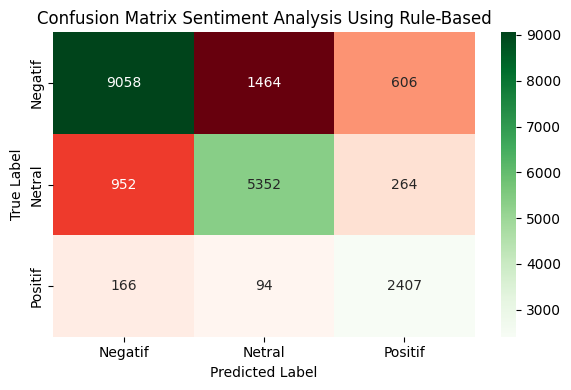


Selesai: evaluasi sentiment rule-based


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

# =========================================================
# SENTIMENT ANALYSIS EVALUATION
# =========================================================

eval_sentiment_df = sentiment_df.copy()
eval_sentiment_df['true_sentiment'] = (
    eval_sentiment_df['true_sentiment'].fillna('').astype(str).str.strip()
)
eval_sentiment_df['final_sentiment_label'] = (
    eval_sentiment_df['final_sentiment_label']
    .fillna('')
    .astype(str)
    .str.strip()
)

eval_sentiment_df = eval_sentiment_df[
    eval_sentiment_df['true_sentiment'] != ''
].reset_index(drop=True)

if eval_sentiment_df.empty:
    raise ValueError(
        'Tidak ada data true_sentiment yang terisi untuk dievaluasi.'
    )

total_data = len(eval_sentiment_df)
total_correct = int(
    (
        eval_sentiment_df['final_sentiment_label']
        == eval_sentiment_df['true_sentiment']
    ).sum()
)
total_wrong = int(total_data - total_correct)
final_accuracy = (total_correct / total_data) if total_data > 0 else 0
error_rate = (total_wrong / total_data) if total_data > 0 else 0
sentiment_f1 = f1_score(
    eval_sentiment_df['true_sentiment'],
    eval_sentiment_df['final_sentiment_label'],
    average='weighted',
    zero_division=0,
)

true_sentiment_counts = (
    eval_sentiment_df['true_sentiment']
    .value_counts()
    .rename_axis('True Sentiment')
    .reset_index(name='Jumlah')
)

predicted_sentiment_counts = (
    eval_sentiment_df['final_sentiment_label']
    .value_counts()
    .rename_axis('Predicted Sentiment')
    .reset_index(name='Jumlah')
)

label_order = ['Negatif', 'Netral', 'Positif']
precision, recall, f1_per_sentiment, support = (
    precision_recall_fscore_support(
        eval_sentiment_df['true_sentiment'],
        eval_sentiment_df['final_sentiment_label'],
        labels=label_order,
        zero_division=0,
    )
)

f1_sentiment_df = pd.DataFrame(
    {
        'Sentiment': label_order,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1_per_sentiment,
        'Jumlah_True': support,
    }
)
f1_sentiment_df[['Precision', 'Recall', 'F1_Score']] = f1_sentiment_df[
    ['Precision', 'Recall', 'F1_Score']
].round(4)

cm = confusion_matrix(
    eval_sentiment_df['true_sentiment'],
    eval_sentiment_df['final_sentiment_label'],
    labels=label_order,
)
final_confusion = pd.DataFrame(cm, index=label_order, columns=label_order)

print('===========================================')
print('HASIL KLASIFIKASI SENTIMENT RULE-BASED')
print('===========================================')
print('Sumber rule              : sentiment.py + kamus polarity')
print('Unit evaluasi            : segmented_text per baris')
print('Distribusi True Sentiment:')
print(true_sentiment_counts.to_markdown(index=False))
print()
print('Distribusi Prediksi Sentiment:')
print(predicted_sentiment_counts.to_markdown(index=False))
print()
print('F1 Score Tiap Sentiment:')
print(f1_sentiment_df.to_markdown(index=False))
print()
print(f'Total Data               : {total_data}')
print(f'Prediksi Benar           : {total_correct}')
print(f'Prediksi Salah           : {total_wrong}')
print(f'Total Akurasi            : {final_accuracy:.2%}')
print(f'Error Rate               : {error_rate:.2%}')
print(f'F1 Score                 : {sentiment_f1:.4f}')

print()
print('Confusion Matrix:')
print(final_confusion)

# ---------------------------------------------------------
# PROSES PLOTTING DENGAN DIAGONAL HIJAU KUSTOM
# ---------------------------------------------------------
plt.figure(figsize=(6, 4))

# Buat masker boolean untuk memisahkan posisi koordinat diagonal
mask_diagonal = np.eye(final_confusion.shape[0], dtype=bool)
mask_off_diagonal = ~mask_diagonal

# Lapisan 1: Plot nilai di luar diagonal dengan warna biru pudar bawaan
ax = sns.heatmap(
    final_confusion,
    annot=True,
    fmt='d',
    cmap='Reds',
    mask=mask_diagonal,
    cbar=False,
)

# Lapisan 2: Plot nilai pada garis diagonal saja menggunakan palet warna Hijau (Greens)
sns.heatmap(
    final_confusion,
    annot=True,
    fmt='d',
    cmap='Greens',
    mask=mask_off_diagonal,
    ax=ax,
    cbar=True,
)

plt.title('Confusion Matrix Sentiment Analysis Using Rule-Based')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# =========================================================
# DATA MISCLASSIFIED DAN CLASSIFIED
# =========================================================

sentiment_export_columns = [
    'comment_id',
    'comment_text',
    'segmented_text',
    'tokens_segmented_text',
    'stemmed_segmented_text',
    'true_aspect',
    'predicted_aspect',
    'similarity_score',
    'true_sentiment',
    'final_sentiment_score',
    'final_sentiment_normalized',
    'final_sentiment_label',
    'type',
]

available_sentiment_export_columns = [
    col for col in sentiment_export_columns if col in eval_sentiment_df.columns
]

misclassified_sentiment_df = eval_sentiment_df.loc[
    eval_sentiment_df['final_sentiment_label']
    != eval_sentiment_df['true_sentiment'],
    available_sentiment_export_columns,
].copy()

classified_sentiment_df = eval_sentiment_df.loc[
    eval_sentiment_df['final_sentiment_label']
    == eval_sentiment_df['true_sentiment'],
    available_sentiment_export_columns,
].copy()

misclassified_sentiment_df.to_csv(
    'output_skenario_1/missclassified_sentiment.csv', index=False, encoding='utf-8-sig'
)

classified_sentiment_df.to_csv(
    'output_skenario_1/classified_sentiment.csv', index=False, encoding='utf-8-sig'
)

# =========================================================
# SIMPAN HASIL LABELING FINAL
# =========================================================

available_result_columns = [
    col for col in sentiment_export_columns if col in sentiment_df.columns
]
result_df = sentiment_df[available_result_columns].copy()
result_df.to_csv(
    'output_skenario_1/result_sentiment_analysis.csv', index=False, encoding='utf-8-sig'
)

print('\nSelesai: evaluasi sentiment rule-based')